In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
income_file = "/Users/karmansingh/INST447_MD_INCOME_VS_HOUSING/files_csv/Maryland_and_Jurisdictions_Median_Household_Income_with_Margin_of_Error__2015-2024.csv"
sales_file = "/Users/karmansingh/INST447_MD_INCOME_VS_HOUSING/files_csv/sumy_total-.csv"
housing_file = "/Users/karmansingh/INST447_MD_INCOME_VS_HOUSING/files_csv/Housing_Inventory_Median_Listing_Price_in_Maryland.csv"


income_raw = pd.read_csv(income_file)
sales_raw = pd.read_csv(sales_file, header=None)
housing_raw = pd.read_csv(housing_file)

print(income_raw.head())

print(sales_raw.head(10))

  Date created  Year     Geography Median Household Income Margin of Error
0   03/13/2026  2024      Maryland             $   102,835       $   1,347
1   03/13/2026  2024      Allegany              $   63,215       $   3,784
2   03/13/2026  2024  Anne Arundel             $   127,042       $   3,768
3   03/13/2026  2024     Baltimore              $   87,865       $   3,822
4   03/13/2026  2024       Calvert             $   121,798       $   6,611
                                                  0            1       2   \
0  Total Residential Sales In And Out Of Priority...          NaN     NaN   
1                                                NaN          NaN     NaN   
2                                                NaN  Total Sales     NaN   
3                                                NaN         2017    2018   
4                                                NaN       Total   Total    
5                                      Jurisdictions        Sales   Sales   
6          

In [5]:
#Clean income data

income = income_raw.copy()

income.columns = income.columns.str.strip().str.lower().str.replace(" ", "_")

income["median_household_income"] = (income["median_household_income"].astype(str).str.replace("$", "", regex=False)
.str.replace(",", "", regex=False).str.strip())

income["margin_of_error"] = (income["margin_of_error"].astype(str).str.replace("$", "", regex=False)
.str.replace(",", "", regex=False).str.strip())

income["median_household_income"] = pd.to_numeric(income["median_household_income"], errors="coerce")
income["margin_of_error"] = pd.to_numeric(income["margin_of_error"], errors="coerce")

income["geography_clean"] = (income["geography"].str.replace(" County", "", regex=False).str.strip().str.upper())

income_clean = income[
    ["year", "geography", "geography_clean", "median_household_income", "margin_of_error"]
].dropna()

income_clean.head()

,year,geography,geography_clean,median_household_income,margin_of_error
0,2024,Maryland,MARYLAND,102835,1347
1,2024,Allegany,ALLEGANY,63215,3784
2,2024,Anne Arundel,ANNE ARUNDEL,127042,3768
3,2024,Baltimore,BALTIMORE,87865,3822
4,2024,Calvert,CALVERT,121798,6611


In [6]:
#Clean residential sales data

sales = sales_raw.copy()

#Rows 0-5 are header rows actual data starts at row 6
sales = sales.iloc[6:].copy()

# Keep first column and columns 1-8, which are Total Sales for 2017-2024
sales = sales[[0, 1, 2, 3, 4, 5, 6, 7, 8]]

sales.columns = [
    "geography",
    "sales_2017",
    "sales_2018",
    "sales_2019",
    "sales_2020",
    "sales_2021",
    "sales_2022",
    "sales_2023",
    "sales_2024"
]

sales = sales.dropna(subset=["geography"])

# Remove blank rows
sales = sales[sales["geography"].astype(str).str.strip() != ""]

# Cleaning geography names
sales["geography_clean"] = (
    sales["geography"]
    .astype(str)
    .str.replace(" County", "", regex=False)
    .str.strip()
    .str.upper()
)

# Converting sales columns to numeric
sales_cols = [
    "sales_2017", "sales_2018", "sales_2019", "sales_2020",
    "sales_2021", "sales_2022", "sales_2023", "sales_2024"
]

for col in sales_cols:
    sales[col] = (
        sales[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("---", "", regex=False)
        .str.replace("-", "", regex=False)
        .str.strip()
    )
    sales[col] = pd.to_numeric(sales[col], errors="coerce")

sales_clean = sales.dropna(subset=["sales_2024"])

sales_clean.head()

,geography,sales_2017,sales_2018,sales_2019,sales_2020,sales_2021,sales_2022,sales_2023,sales_2024,geography_clean
6,MARYLAND,77413.0,76193.0,82073.0,82220.0,111705.0,92581.0,64339.0,65531.0,MARYLAND
8,BALTIMORE REGION,36106.0,35882.0,38210.0,35426.0,51212.0,43911.0,30061.0,30406.0,BALTIMORE REGION
9,Anne Arundel County,9373.0,9229.0,10215.0,9973.0,12588.0,10433.0,6901.0,7000.0,ANNE ARUNDEL
10,Baltimore County,10047.0,9830.0,10316.0,9347.0,13931.0,12380.0,8288.0,9089.0,BALTIMORE
11,Carroll County,2301.0,2273.0,2263.0,2578.0,3026.0,2599.0,1680.0,1595.0,CARROLL


In [7]:
#Reshape sales data

sales_long = sales_clean.melt(
    id_vars=["geography", "geography_clean"],
    value_vars=sales_cols,
    var_name="year",
    value_name="total_residential_sales"
)

sales_long["year"] = sales_long["year"].str.replace("sales_", "").astype(int)

sales_long.head()

,geography,geography_clean,year,total_residential_sales
0,MARYLAND,MARYLAND,2017,77413.0
1,BALTIMORE REGION,BALTIMORE REGION,2017,36106.0
2,Anne Arundel County,ANNE ARUNDEL,2017,9373.0
3,Baltimore County,BALTIMORE,2017,10047.0
4,Carroll County,CARROLL,2017,2301.0


In [8]:
#Clean housing data
housing = housing_raw.copy()

housing["observation_date"] = pd.to_datetime(housing["observation_date"])

#Since data is yearly and not monthly create a year column
housing["year"] = housing["observation_date"].dt.year

#Aggregate monthly into yearly. 
housing_clean = housing.groupby("year")["MEDLISPRIMD"].mean().reset_index()

housing_clean = housing_clean.rename(columns={"MEDLISPRIMD": "median_listing_price"})
housing_clean["median_listing_price"] = housing_clean["median_listing_price"].round(2)

housing_clean

,year,median_listing_price
0,2016,298158.33
1,2017,312077.67
2,2018,325063.17
3,2019,338057.17
4,2020,349334.00
5,2021,364039.50
6,2022,389612.50
7,2023,419160.67
8,2024,416474.17
9,2025,434301.92


In [9]:
#Merge data
merged = pd.merge(
    income_clean,
    sales_long,
    on=["year", "geography_clean"],
    how="inner"
)

merged = pd.merge(
    merged,
    housing_clean,
    on="year",
    how="inner"
)

merged["price_to_income_ratio"] = (
    merged["median_listing_price"] / merged["median_household_income"]
).round(2)

merged.head()

,year,geography_x,geography_clean,median_household_income,margin_of_error,geography_y,total_residential_sales,median_listing_price,price_to_income_ratio
0,2024,Maryland,MARYLAND,102835,1347,MARYLAND,65531.0,416474.17,4.05
1,2024,Allegany,ALLEGANY,63215,3784,Allegany County,680.0,416474.17,6.59
2,2024,Anne Arundel,ANNE ARUNDEL,127042,3768,Anne Arundel County,7000.0,416474.17,3.28
3,2024,Baltimore,BALTIMORE,87865,3822,Baltimore County,9089.0,416474.17,4.74
4,2024,Calvert,CALVERT,121798,6611,Calvert County,1081.0,416474.17,3.42


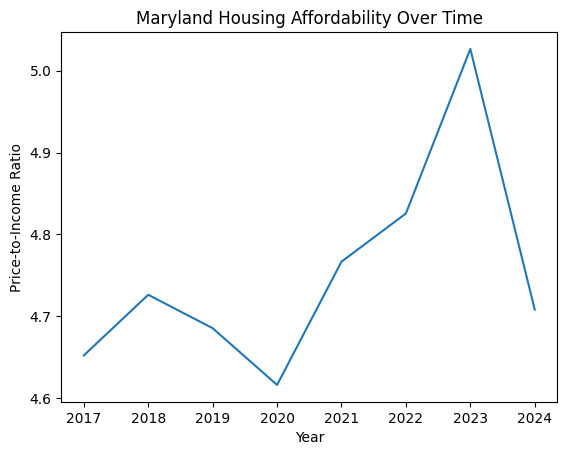

In [10]:
plt.plot(merged.groupby("year")["price_to_income_ratio"].mean())

plt.xlabel("Year")
plt.ylabel("Price-to-Income Ratio")
plt.title("Maryland Housing Affordability Over Time")
plt.show()

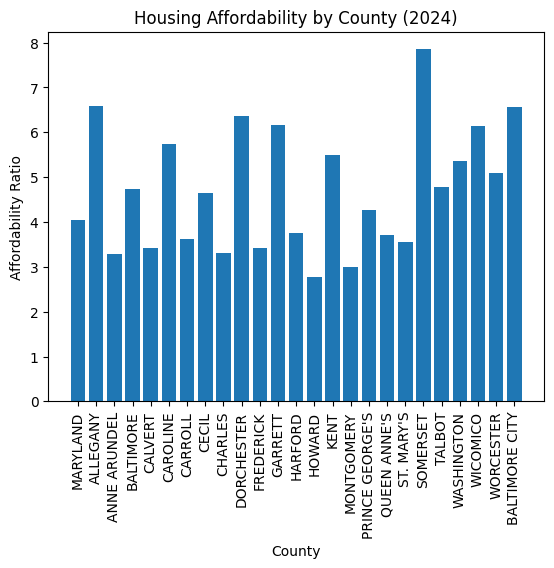

In [11]:
latest = merged[merged["year"] == 2024]

plt.bar(latest["geography_clean"], latest["price_to_income_ratio"])

plt.xticks(rotation=90)
plt.xlabel("County")
plt.ylabel("Affordability Ratio")
plt.title("Housing Affordability by County (2024)")
plt.show()

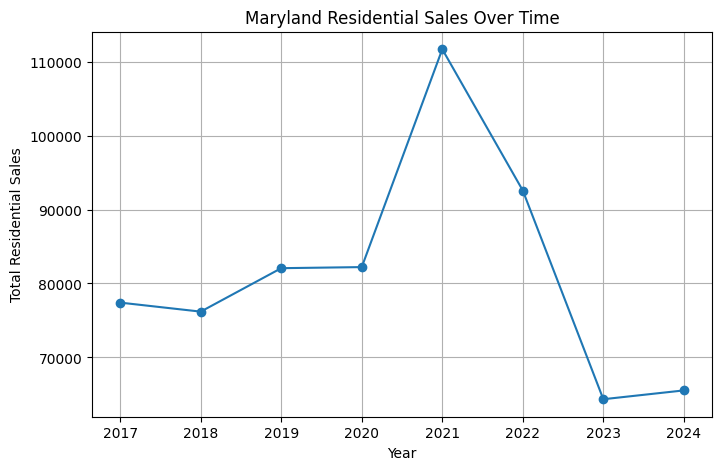

In [12]:
maryland = merged[merged["geography_clean"] == "MARYLAND"]

plt.figure(figsize=(8,5))
plt.plot(maryland["year"], maryland["total_residential_sales"], marker="o")
plt.xlabel("Year")
plt.ylabel("Total Residential Sales")
plt.title("Maryland Residential Sales Over Time")
plt.grid(True)

plt.show()